In [1]:
import os
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as TF  # Das fixiert den NameError
import matplotlib.pyplot as plt

# Device Selection (GPU/CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Training auf GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Training auf CPU (Langsam!)")

def read_pfm(file):
    with open(file, "rb") as f:
        header = f.readline().decode('utf-8').rstrip()
        if header == 'PF':
            color = True
        elif header == 'Pf':
            color = False
        else:
            raise Exception('Keine PFM Datei.')

        dims = f.readline().decode('utf-8').split()
        width = int(dims[0])
        height = int(dims[1])

        scale = float(f.readline().decode('utf-8').rstrip())
        # Negativer Scale bedeutet Little Endian (Standard bei SceneFlow)
        if scale < 0:
            endian = '<'
            scale = -scale
        else:
            endian = '>'

        data = np.fromfile(f, endian + 'f')
        shape = (height, width, 3) if color else (height, width)

        data = np.reshape(data, shape)
        data = np.flipud(data) # PFM speichert von unten nach oben
        
        # WICHTIG: Inf-Werte abfangen
        data[data == np.inf] = 0
        
        return data.copy()

    return data

Training auf GPU: NVIDIA GeForce RTX 3080 Ti


In [2]:
class StereoDataset(torch.utils.data.Dataset):
    def __init__(self, left_dir, right_dir, disp_dir, training=True):
        self.left_paths = sorted([os.path.join(left_dir, f) for f in os.listdir(left_dir) if f.endswith('.png')])
        self.right_paths = sorted([os.path.join(right_dir, f) for f in os.listdir(right_dir) if f.endswith('.png')])
        self.disp_paths = sorted([os.path.join(disp_dir, f) for f in os.listdir(disp_dir) if f.endswith('.pfm')])
        self.training = training
        self.to_tensor = transforms.ToTensor()
        self.MAX_DISP_TARGET = 196.0 # Unser neuer Standard

    def __len__(self):
        return len(self.left_paths)

    def augment(self, left, right, disp):
        # 1. KEIN HFLIP MEHR! (Verwirrt die Stereo-Geometrie)
        
        # 2. Helligkeits-Varianz (Simuliert Sensor-Differenzen)
        if random.random() > 0.2:
            brightness_l = random.uniform(0.9, 1.1)
            brightness_r = random.uniform(0.9, 1.1)
            left = TF.adjust_brightness(left, brightness_l)
            right = TF.adjust_brightness(right, brightness_r)

        # 3. Sensor-Rauschen (Wichtig für reale Roboter-Kameras)
        if random.random() > 0.5:
            noise_sigma = random.uniform(0, 0.02)
            left = torch.clamp(left + torch.randn_like(left) * noise_sigma, 0, 1)
            right = torch.clamp(right + torch.randn_like(right) * noise_sigma, 0, 1)

        return left, right, disp

    def __getitem__(self, idx):
        # 1. Bilder laden
        left_img = Image.open(self.left_paths[idx]).convert('L')
        right_img = Image.open(self.right_paths[idx]).convert('L')
        
        # 2. Bilder auf Zielgröße bringen
        left_img = left_img.resize((640, 480), Image.BILINEAR)
        right_img = right_img.resize((640, 480), Image.BILINEAR)
        
        # 3. In Tensoren wandeln [0.0, 1.0]
        left = self.to_tensor(left_img)
        right = self.to_tensor(right_img)

        # 4. PFM Disparität laden
        disp_np = read_pfm(self.disp_paths[idx])
        disp_np = np.abs(disp_np)
        disp_np[~np.isfinite(disp_np)] = 0
        
        # 5. Skalierung der Disparitätswerte auf neue Breite (640)
        original_width = disp_np.shape[1]
        scale_factor = 640.0 / original_width
        
        disp = torch.from_numpy(disp_np.copy()).float().unsqueeze(0)
        disp = disp * scale_factor # Hier entstehen die echten Pixelwerte (z.B. 120.5 px)
        
        # 6. Resizing der Disparitäts-Karte auf 480x640
        disp = F.interpolate(disp.unsqueeze(0), size=(480, 640), mode='nearest').squeeze(0)

        # 7. Augmentation
        if self.training:
            left, right, disp = self.augment(left, right, disp)

        # 8. WICHTIG: KEINE NORMIERUNG MEHR AUF 0-1!
        # Wir begrenzen nur auf unser Hardware-Maximum von 196
        disp_final = torch.clamp(disp, 0, self.MAX_DISP_TARGET)

        return left, right, disp_final

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DWResidualLite(nn.Module):
    """
    Hailo-freundlicher Residual Block: 
    Nutzt Depthwise-Separable Convolutions zur Reduktion der Parameter.
    """
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            # Depthwise: Räumliche Filterung
            nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            # Pointwise: Kanal-Mischung
            nn.Conv2d(in_ch, out_ch, 1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv(x)
        out += self.shortcut(x)
        return out

class StereoNetLite_Grabber(nn.Module):
    def __init__(self, max_disp=196):
        super().__init__()
        self.max_disp = max_disp
        self.cv_shifts = max_disp // 4 # 49 Shifts

        # 1. Feature Extractor (1/4 Auflösung)
        # Nutzt DW-Residuals für stabilere Kantenmerkmale
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            DWResidualLite(16, 24, stride=2), # 1/2 Auflösung
            DWResidualLite(24, 32, stride=2)  # 1/4 Auflösung
        )

        # 2. Cost Volume Aggregator
        # Reduziert 1568 Channels effizient auf eine grobe Disparitätskarte
        self.aggregator = nn.Sequential(
            nn.Conv2d(32 * self.cv_shifts, 96, 1, bias=False), 
            nn.BatchNorm2d(96), nn.ReLU(inplace=True),
            nn.Conv2d(96, 96, 3, padding=1, groups=96, bias=False), # Spatial Processing
            nn.BatchNorm2d(96), nn.ReLU(inplace=True),
            nn.Conv2d(96, 32, 1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 3, padding=1, bias=False)
        )

        # 3. Grabber-Refinement (Fokus auf Flächen & Sub-Pixel Genauigkeit)
        self.refine = nn.Sequential(
            nn.Conv2d(2, 16, 3, padding=1, bias=False),
            nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            # Dilation von 2 auf 4 erhöht -> Receptive Field wächst massiv!
            # Wichtig: Padding muss auch 4 sein, damit die Größe gleich bleibt.
            nn.Conv2d(16, 16, 3, padding=4, dilation=4, groups=16, bias=False), 
            nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, 3, padding=1, bias=False)
        )
        
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        # WICHTIG: Refinement sehr klein starten, um disp_low zu erhalten
        nn.init.constant_(self.refine[-1].weight, 0.001)

    def forward(self, left, right):
        f_l = self.feature_extractor(left)
        f_r = self.feature_extractor(right)

        volume = [f_l]
        for i in range(1, self.cv_shifts):
            shift = F.pad(f_r[:, :, :, i:], (0, i, 0, 0), mode='replicate')
            volume.append(shift)
    
        cv = torch.cat(volume, dim=1)
        disp_4 = self.aggregator(cv)
    
        # Basis-Disparität
        disp_low = F.interpolate(disp_4, scale_factor=4, mode='bilinear', align_corners=False)
        disp_low = disp_low * 4.0 

        # Residual Refinement
        combined = torch.cat([left, disp_low / self.max_disp], dim=1)
        residual = self.refine(combined)
    
        # Optional: Tanh-Skalierung, um das Residual auf z.B. +-20 Pixel zu begrenzen
        # residual = torch.tanh(residual) * 20.0 

        final_disp = disp_low + residual

        if self.training:
            return final_disp, disp_low
        return final_disp

In [4]:
import torch.nn.functional as F

def warp(right_img, disp):
    """
    Rekonstruiert das linke Bild aus dem rechten Bild und der Disparität.
    Erwartet: disp in Pixelkoordinaten (nicht normiert).
    """
    B, C, H, W = right_img.size()

    # Erzeuge Basis-Gitter in Pixelkoordinaten
    grid_x, grid_y = torch.meshgrid(
        torch.arange(W, device=right_img.device),
        torch.arange(H, device=right_img.device),
        indexing='xy'
    )
    grid_x = grid_x.unsqueeze(0).expand(B, -1, -1).float()
    grid_y = grid_y.unsqueeze(0).expand(B, -1, -1).float()

    # Verschiebe X-Koordinaten um Disparität (rechtes Bild → linkes Bild)
    shifted_x = grid_x - disp.squeeze(1)  # Disparität abziehen

    # Normiere auf [-1, 1] für grid_sample
    norm_x = 2.0 * shifted_x / (W - 1) - 1.0
    norm_y = 2.0 * grid_y / (H - 1) - 1.0

    vgrid = torch.stack((norm_x, norm_y), dim=3)

    return F.grid_sample(right_img, vgrid, mode='bilinear', padding_mode='border', align_corners=True)

def edge_aware_smoothness_loss(pred_disp, left_img):
    """ Bestraft Disparitäts-Sprünge, wo keine Bild-Kanten sind. """
    def gradient_x(img): return torch.abs(img[:, :, :, :-1] - img[:, :, :, 1:])
    def gradient_y(img): return torch.abs(img[:, :, :-1, :] - img[:, :, 1:, :])

    disp_grad_x = gradient_x(pred_disp)
    disp_grad_y = gradient_y(pred_disp)

    # Bild-Gradienten zur Gewichtung (Kanten im Originalbild erlauben Kanten in der Disparität)
    img_grad_x = torch.mean(gradient_x(left_img), dim=1, keepdim=True)
    img_grad_y = torch.mean(gradient_y(left_img), dim=1, keepdim=True)

    weight_x = torch.exp(-img_grad_x)
    weight_y = torch.exp(-img_grad_y)

    return (disp_grad_x * weight_x).mean() + (disp_grad_y * weight_y).mean()

def stereo_loss(pred_final, pred_low, gt, left_img, alpha=1.5):
    """
    Kombinierter Loss für StereoNetLite.
    - pred_final: Output des Refinement (Full Res)
    - pred_low:   Output des Aggregators (Full Res upsampled)
    - gt:         Ground Truth Disparität
    - alpha:      Gewichtung des Edge-Aware Smoothness Loss
    """
    # Maske für gültige Pixel (GT > 0)
    mask = gt > 0
    if not mask.any():
        return torch.tensor(0.0, device=pred_final.device, requires_grad=True)

    # 1. Glatter L1 Loss (Huber) ist robuster gegen Ausreißer als reiner L1
    # Wir gewichten das Finale Ergebnis mit 0.7 und die Basis mit 0.3
    loss_final = F.smooth_l1_loss(pred_final[mask], gt[mask], reduction='mean')
    loss_low   = F.smooth_l1_loss(pred_low[mask], gt[mask], reduction='mean')
    
    data_loss = 0.5 * loss_final + 0.5 * loss_low

    # 2. Edge-Aware Smoothness Loss (Das "Bügeleisen")
    # Verhindert den Doppelbalken, indem es Flächen glättet, aber Kanten schont
    def gradient_x(img):
        return img[:, :, :, :-1] - img[:, :, :, 1:]
    def gradient_y(img):
        return img[:, :, :-1, :] - img[:, :, 1:, :]

    # Gradienten der Vorhersage
    disp_grad_x = gradient_x(pred_final)
    disp_grad_y = gradient_y(pred_final)

    # Gradienten des Bildes (als Gewichtung für die Kanten)
    img_grad_x = torch.mean(gradient_x(left_img), dim=1, keepdim=True)
    img_grad_y = torch.mean(gradient_y(left_img), dim=1, keepdim=True)

    # Gewichte: Wo das Bild starke Kanten hat, darf die Disparität springen
    weight_x = torch.exp(-torch.abs(img_grad_x))
    weight_y = torch.exp(-torch.abs(img_grad_y))

    smoothness_loss = torch.mean(torch.abs(disp_grad_x) * weight_x) + \
                      torch.mean(torch.abs(disp_grad_y) * weight_y)

    # Gesamtverlust
    total_loss = data_loss + alpha * smoothness_loss
    
    return total_loss



import time
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from tqdm.auto import tqdm # Import für den Fortschrittsbalken

def train_production(model, train_loader, test_dataset, epochs=100, lr=1e-4, start_epoch=25, alpha_smooth=1.5):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=(epochs - start_epoch))
    
    log_file = "training_log.txt"
    print(f"🚀 Power-Restart mit Deep Supervision | Alpha: {alpha_smooth}")

    for epoch in range(start_epoch, epochs):
        model.train()
        epoch_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for i, (left, right, gt_disp) in enumerate(pbar):
            left, right, gt_disp = left.to(device), right.to(device), gt_disp.to(device)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                # Das Modell gibt jetzt zwei Werte zurück!
                pred_final, pred_low = model(left, right)
                
                # Multi-Scale Loss berechnen
                # Inside your epoch loop:
                if epoch < 10:
                    current_alpha = 0.1  # Let it find the depth first
                elif epoch < 20:
                    current_alpha = 0.5  # Start smoothing
                else:
                    current_alpha = alpha_smooth # Final value (1.5)
                loss = stereo_loss(pred_final, pred_low, gt_disp, left, alpha=current_alpha)
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            if i % 10 == 0:
                torch.cuda.synchronize()
                time.sleep(0.002)
            
            epoch_loss += loss.item()
            if i % 10 == 0:
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        
        # Logging
        with open(log_file, "a") as f:
            f.write(f"{epoch+1},{avg_loss:.4f},{optimizer.param_groups[0]['lr']:.2e},{current_alpha}\n")

        # Visualisierung (nutzt intern model.eval(), wo nur 1 Wert kommt)
        save_debug_visuals(model, test_dataset, epoch, index=6)
        save_preview(model, test_dataset, f"epoch_{epoch+1}_final", index=6, warp_func=warp)
        if (epoch + 1) % 5 == 0:
            torch.save(model.state_dict(), f"StereoNetLite_DeepSupervision_ep_{epoch+1}.pth")

    print("✅ Training beendet.")



# Aufruf auf der 3080 Ti
# train_production(model, train_loader, dataset, epochs=50)

/home/slarc/miniconda3/envs/stereo_wsl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def save_debug_visuals(model, dataset, epoch, index=6):
    model.eval()
    with torch.no_grad():
        left, right, target = dataset[index]
        left_in = left.unsqueeze(0).to(device)
        right_in = right.unsqueeze(0).to(device)
        
        # --- Schritt 1: Features & Cost Volume ---
        f_l = model.feature_extractor(left_in)
        f_r = model.feature_extractor(right_in)
        
        volume = [f_l]
        for i in range(1, model.cv_shifts):
            shift = F.pad(f_r[:, :, :, i:], (0, i, 0, 0), mode='replicate')
            volume.append(shift)
        cv = torch.cat(volume, dim=1)
        
        # --- Schritt 2: Aggregator (1/4 Disp) ---
        disp_4 = model.aggregator(cv)
        
        # --- Schritt 3: Upsampling ---
        disp_low = F.interpolate(disp_4, scale_factor=4, mode='bilinear', align_corners=False) * 4.0
        
        # --- Schritt 4: Finales Refinement ---
        combined = torch.cat([left_in, disp_low / model.max_disp], dim=1)
        residual = model.refine(combined)
        final_disp = disp_low + residual

        # --- Plotting ---
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
        # Wir zeigen: Grober Output, Das was das Refinement ändern will, Das Ergebnis, Das Ziel
        imgs = [
            disp_low.squeeze().cpu().numpy(), 
            residual.squeeze().cpu().numpy(), 
            final_disp.squeeze().cpu().numpy(), 
            target.squeeze().cpu().numpy()
        ]
        titles = [
            f"1. Upsampled (Base)", 
            f"2. Residual (Correction)", 
            f"3. Final Result", 
            "4. Ground Truth"
        ]
        
        for ax, img, title in zip(axes, imgs, titles):
            # Nutze 'jet' für Disparität, aber 'RdBu' für den Residual-Schritt (um Änderungen zu sehen)
            cmap = 'jet' if "Residual" not in title else 'RdBu'
            v_min, v_max = (0, 196) if "Residual" not in title else (-10, 10)
            
            im = ax.imshow(img, cmap=cmap, vmin=v_min, vmax=v_max)
            ax.set_title(title)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            ax.axis('off')
        
        plt.savefig(f"training_progress/debug_epoch_{epoch+1}.png", bbox_inches='tight')
        plt.close(fig)
    model.train()

def save_preview(model, dataset, name, index=6, warp_func=None):
    model.eval()
    with torch.no_grad():
        left, right, target = dataset[index]
        left_in = left.unsqueeze(0).to(device)
        right_in = right.unsqueeze(0).to(device)
        
        pred = model(left_in, right_in)
        
        # Warp-Rekonstruktion
        recon_left = None
        if warp_func is not None:
            recon_left = warp_func(right_in, pred)
            recon_left = recon_left.squeeze().cpu().numpy()

        # Konvertierung für Plotting (Wertebereich 0 bis MAX_DISP)
        pred_np = pred.squeeze().cpu().numpy()
        gt_np = target.squeeze().cpu().numpy()
        left_np = left.squeeze().cpu().numpy()
        
        fig, ax = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. Ground Truth (Skala 0 bis 196)
        im0 = ax[0].imshow(gt_np, cmap='jet', vmin=0, vmax=196)
        ax[0].set_title(f"GT (Index {index})")
        plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
        
        # 2. Vorhersage (Skala 0 bis 196)
        # Jetzt vergleichbar mit GT!
        im1 = ax[1].imshow(pred_np, cmap='jet', vmin=0, vmax=196)
        ax[1].set_title(f"Vorhersage: {name}")
        plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
        
        # 3. Warp-Check (Qualitätskontrolle)
        if recon_left is not None:
            ax[2].imshow(recon_left, cmap='gray')
            ax[2].set_title("Rekonstruktion aus Rechts")
        else:
            ax[2].imshow(left_np, cmap='gray')
            ax[2].set_title("Original Links")
        
        for a in ax: a.axis('off')

        import os
        os.makedirs("training_progress", exist_ok=True)
        plt.savefig(f"training_progress/StereoNetLite_Grabber_preview_{name}.png", bbox_inches='tight')
        plt.close(fig) 
        
    model.train()

--- Sanity Check: Index 0 ---
✓ Erfolgreich geladen in 0.1255 Sekunden
✓ Shape Left: torch.Size([1, 480, 640])
✓ Shape Disp: torch.Size([1, 480, 640])
✓ Max Disparität: 101.35 Pixel
✓ Durchschnittliche Tiefe: 20.93 Pixel
✅ Skalierung korrekt: Bereich 0 bis 101.35 Pixel.


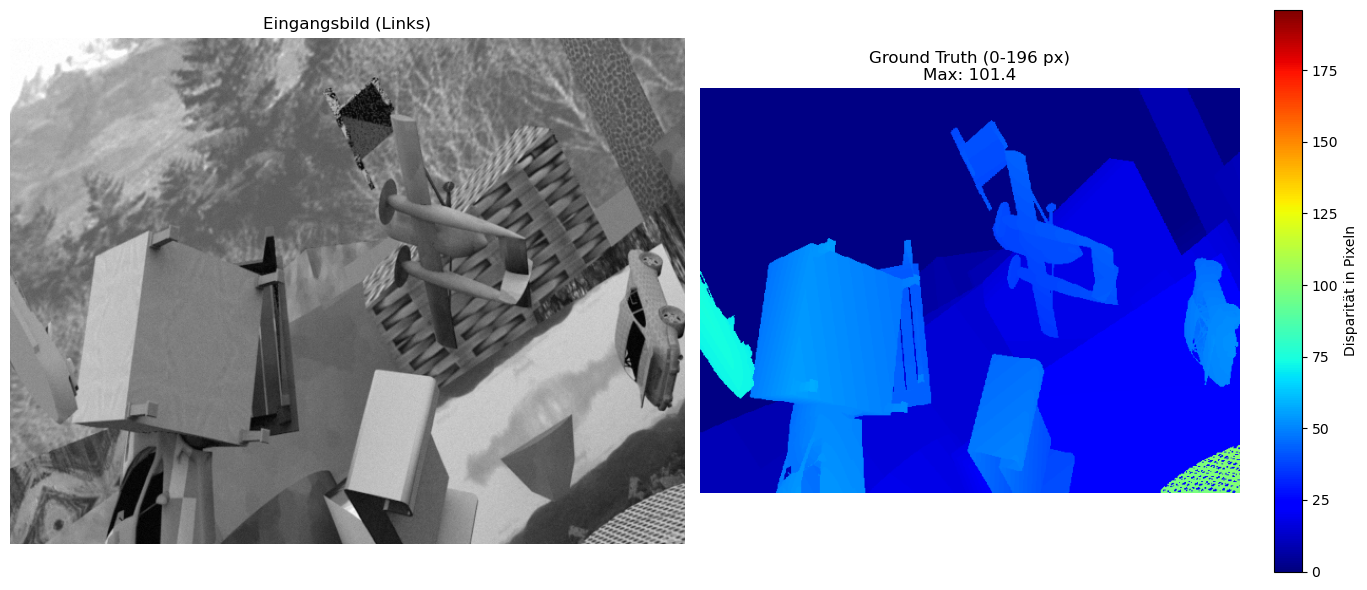

In [6]:
import time
import matplotlib.pyplot as plt

def check_dataset_sanity(dataset, index=0):
    print(f"--- Sanity Check: Index {index} ---")
    start_time = time.time()
    
    try:
        left, right, disp = dataset[index]
        load_time = time.time() - start_time
        
        # Statistiken berechnen
        max_val = disp.max().item()
        mean_val = disp.mean().item()
        
        print(f"✓ Erfolgreich geladen in {load_time:.4f} Sekunden")
        print(f"✓ Shape Left: {left.shape}")
        print(f"✓ Shape Disp: {disp.shape}")
        print(f"✓ Max Disparität: {max_val:.2f} Pixel")
        print(f"✓ Durchschnittliche Tiefe: {mean_val:.2f} Pixel")

        # Validierung der Skalierung
        if max_val <= 1.01:
            print("⚠️ WARNUNG: Die Disparität ist noch auf 0-1 normiert!")
            print("   Stelle sicher, dass Zelle 2 'return left, right, disp_final' (0-196) ausgibt.")
        elif max_val > 196.1:
            print(f"⚠️ WARNUNG: Max Disp ({max_val:.2f}) überschreitet das Limit von 196!")
        else:
            print(f"✅ Skalierung korrekt: Bereich 0 bis {max_val:.2f} Pixel.")

        # Visualisierung
        fig, ax = plt.subplots(1, 2, figsize=(14, 6))
        
        # Eingangsbild
        img_display = left.permute(1, 2, 0).numpy()
        ax[0].imshow(img_display, cmap='gray')
        ax[0].set_title("Eingangsbild (Links)")
        ax[0].axis('off')
        
        # Disparität (Wichtig: vmin/vmax auf den neuen Bereich 0-196)
        im = ax[1].imshow(disp.squeeze().numpy(), cmap='jet', vmin=0, vmax=196)
        ax[1].set_title(f"Ground Truth (0-196 px)\nMax: {max_val:.1f}")
        ax[1].axis('off')
        
        # Farbbalken hinzufügen für besseres Verständnis
        plt.colorbar(im, ax=ax[1], label="Disparität in Pixeln")
        
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ FEHLER beim Laden von Index {index}:")
        import traceback
        traceback.print_exc()

# Aufruf
# check_dataset_sanity(dataset, index=0)
dataset = StereoDataset(
    left_dir='/mnt/c/temp/sceneflow/left', 
    right_dir='/mnt/c/temp/sceneflow/right', 
    disp_dir='/mnt/c/temp/sceneflow/disp'
)

check_dataset_sanity(dataset, index=0)

In [ ]:
def main():
    torch.cuda.empty_cache()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Datensätze vorbereiten
    train_dataset = StereoDataset(
        left_dir='/mnt/c/temp/sceneflow/left', 
        right_dir='/mnt/c/temp/sceneflow/right', 
        disp_dir='/mnt/c/temp/sceneflow/disp',
        training=True
    )

    test_dataset = StereoDataset(
        left_dir='/mnt/c/temp/sceneflow/left', 
        right_dir='/mnt/c/temp/sceneflow/right', 
        disp_dir='/mnt/c/temp/sceneflow/disp',
        training=False
    )

    train_loader = DataLoader(
        train_dataset, 
        batch_size=24, 
        shuffle=True, 
        num_workers=12, 
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=3
    )

    # 2. Modell instanziieren
    model = StereoNetLite_Grabber(max_disp=196).to(device)
    
    # --- RESTART LOGIK ---
    last_epoch = 0 # Wir laden den letzten guten Stand vor der Stagnation
    checkpoint_path = f"StereoNetLite_Grabber_epoch_{last_epoch}.pth"
    
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path))
        print(f"✅ Checkpoint {checkpoint_path} geladen. Wir beheben jetzt das Flächen-Problem.")
    else:
        print(f"⚠️ Achtung: {checkpoint_path} nicht gefunden! Starte bei 0.")
        last_epoch = 0
                
    # 3. TRAINING STARTEN (mit Alpha=1.0 für glatte Flächen)
    train_production(
        model, 
        train_loader,
        test_dataset=test_dataset,
        epochs=100,           # Wir zielen auf insgesamt 100 Epochen ab
        lr=1.0e-4,           # "Wachmacher"-Lernrate
        start_epoch=last_epoch,
        alpha_smooth=1.5     # Hier ist der Hebel für die Löcher!
    )

if __name__ == '__main__':
    main()



/tmp/ipykernel_50375/1473880963.py:103: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


⚠️ Achtung: StereoNetLite_Grabber_epoch_0.pth nicht gefunden! Starte bei 0.
🚀 Power-Restart mit Deep Supervision | Alpha: 1.5


Epoch 1/100:   0%|                                                                   | 0/1087 [00:00<?, ?it/s]/tmp/ipykernel_50375/1473880963.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 22/100:  29%|███████████▉                              | 310/1087 [01:43<03:42,  3.49it/s, loss=13.9254]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Epoch 83/100:   9%|███▉                                       | 99/1087 [00:41<04:38,  3.55it/s, loss=13.4514]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set